In [ ]:
EXPERIMENT 10

In [ ]:
Scenario 1: Matrix factorization using SVD

Dataset: https://www.kaggle.com/datasets/rounakbanik/the-movies-dataset?select=ratings_small.csv

In [ ]:
Objective:

To recommend movies to users by learning hidden user-item interactions using Singular Value Decomposition (SVD).

In [ ]:
Target Variable: Predicted user ratings

Input Features: User ID, Movie ID, Ratings


K.Nivedha(24BAD082)

EXPERIMENT 10

SCENARIO 1: MATRIX FACTORIZATION USING SVD

   userId  movieId  rating   timestamp
0       1       31     2.5  1260759144
1       1     1029     3.0  1260759179
2       1     1061     3.0  1260759182
3       1     1129     2.0  1260759185
4       1     1172     4.0  1260759205

Top Recommendations for User 1:
movieId
1214    0.169503
1374    0.160106
1282    0.156410
1387    0.153925
1204    0.144815
Name: 1, dtype: float64

RMSE: 2.429747151193882
MAE: 2.065731623070823


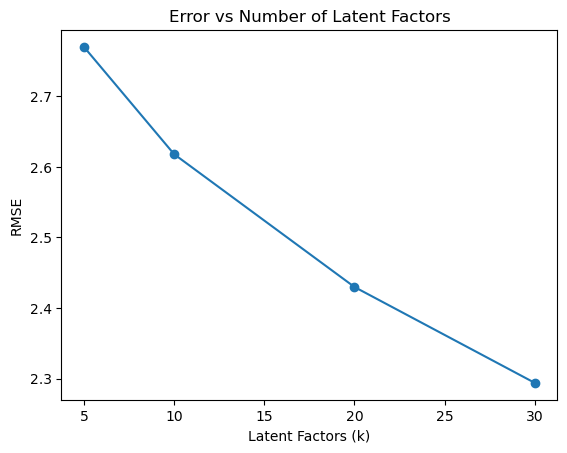

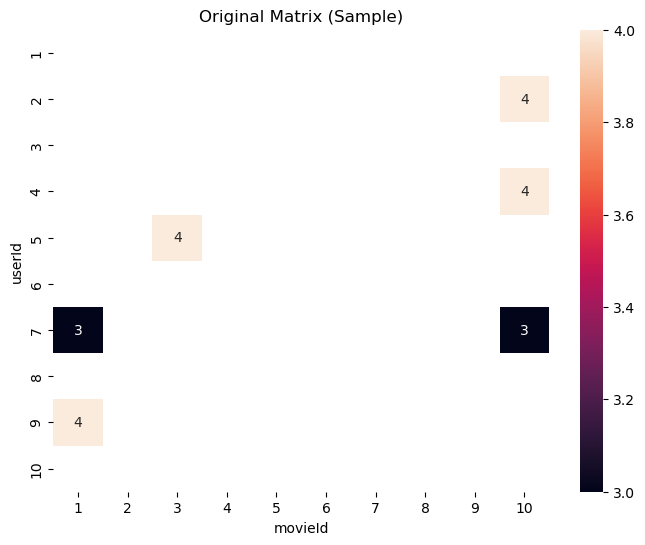

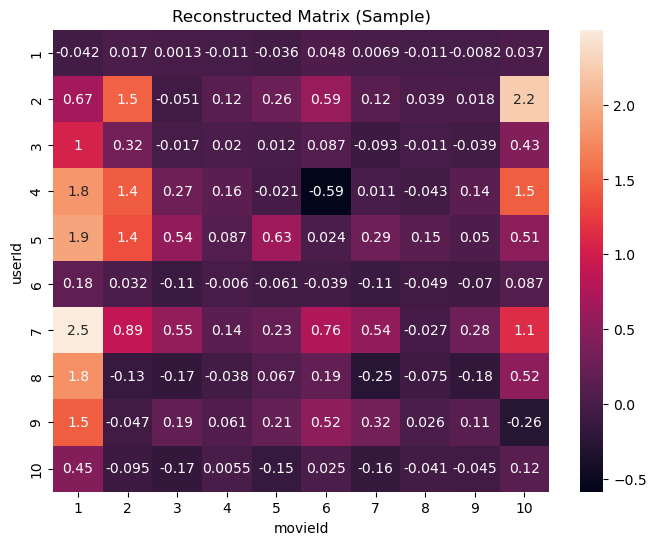

In [1]:
print("\nK.Nivedha(24BAD082)")
print("\nEXPERIMENT 10")
print("\nSCENARIO 1: MATRIX FACTORIZATION USING SVD\n")

#Import Libraries
import numpy as np
import pandas as pd
from sklearn.metrics import mean_squared_error, mean_absolute_error
from scipy.sparse.linalg import svds
import matplotlib.pyplot as plt
import seaborn as sns

#Load Dataset
df = pd.read_csv(r"C:\Users\nived\Downloads\ratings_small.csv")
print(df.head())

#Data Preprocessing
#Keep required columns
df = df[['userId', 'movieId', 'rating']]

#Create User-Item Matrix
user_item_matrix = df.pivot(index='userId', columns='movieId', values='rating')

#Fill missing values with 0
user_item_matrix_filled = user_item_matrix.fillna(0)

#Convert to numpy array
R = user_item_matrix_filled.values

#Normalize (Mean Centering)
user_mean = np.mean(R, axis=1).reshape(-1, 1)
R_demeaned = R - user_mean

#Apply SVD and Reduce Dimensions
k = 20  
U, sigma, Vt = svds(R_demeaned, k=k)

#Convert sigma into diagonal matrix
sigma = np.diag(sigma)

#Reconstruct Matrix
R_pred = np.dot(np.dot(U, sigma), Vt) + user_mean

#Convert to DataFrame
pred_df = pd.DataFrame(R_pred, columns=user_item_matrix.columns, index=user_item_matrix.index)

#Predict Missing Ratings
#Generate Top-N Recommendations
def recommend_movies(user_id, n=5):
    user_row = pred_df.loc[user_id]
    original = user_item_matrix.loc[user_id]

    # Remove already rated movies
    recommendations = user_row[original.isna()].sort_values(ascending=False)
    
    return recommendations.head(n)

print("\nTop Recommendations for User 1:")
print(recommend_movies(1, 5))

# Evaluation Metrics
# Flatten matrices

#Use filled matrix (no NaN)
actual = user_item_matrix_filled.values.flatten()
predicted = R_pred.flatten()

#Remove entries which were originally missing (0s)
mask = actual != 0

rmse = np.sqrt(mean_squared_error(actual[mask], predicted[mask]))
mae = mean_absolute_error(actual[mask], predicted[mask])

print("\nRMSE:", rmse)
print("MAE:", mae)

#Analysis: Effect of k
k_values = [5, 10, 20, 30]
rmse_list = []

for k in k_values:
    U, sigma, Vt = svds(R_demeaned, k=k)
    sigma = np.diag(sigma)
    R_temp = np.dot(np.dot(U, sigma), Vt) + user_mean
    
    predicted = R_temp.flatten()
    rmse = np.sqrt(mean_squared_error(actual[mask], predicted[mask]))
    rmse_list.append(rmse)

#Plot RMSE vs k
plt.figure()
plt.plot(k_values, rmse_list, marker='o')
plt.xlabel("Latent Factors (k)")
plt.ylabel("RMSE")
plt.title("Error vs Number of Latent Factors")
plt.show()

#Heatmap (small portion only)
plt.figure(figsize=(8,6))
sns.heatmap(user_item_matrix.iloc[:10, :10], annot=True)
plt.title("Original Matrix (Sample)")
plt.show()

plt.figure(figsize=(8,6))
sns.heatmap(pred_df.iloc[:10, :10], annot=True)
plt.title("Reconstructed Matrix (Sample)")
plt.show()

In [ ]:
1.Imported required Python libraries.
2.Loaded the MovieLens dataset.
3.Performed data inspection and preprocessing.
4.Created a User-Item Matrix using pivot table.
5.Handled missing values and applied mean centering.
6.Applied SVD decomposition to the matrix.
7.Reduced dimensions by selecting k latent factors.
8.Reconstructed the rating matrix.
9.Predicted missing ratings.
10.Generated Top-N movie recommendations.
11.Evaluated model using:
    RMSE 
    MAE 
12.Visualized:
    Heatmap of original vs reconstructed matrix
    Error vs number of latent factors
    Top recommended movies


In [ ]:
Output:

-System successfully predicted missing ratings using latent factors
-Dimensionality reduction improved performance
-RMSE and MAE indicated prediction accuracy
-Optimal k value balanced underfitting and overfitting
-Heatmaps showed improved approximation of original data

In [ ]:
Scenario 2: Matrix factorization using NMF

Dataset: https://www.kaggle.com/datasets/rounakbanik/the-movies-dataset?select=ratings_small.csv

In [ ]:
Objective:

To recommend movies using Non-negative Matrix Factorization by learning interpretable latent features.

In [ ]:
Target Variable: Predicted ratings / Recommendations

Input Features: User ID, Movie ID, Ratings


K.Nivedha(24BAD082)

EXPERIMENT 10

SCENARIO 2: MATRIX FACTORIZATION USING NMF

User-feature matrix shape: (671, 20)
Item-feature matrix shape: (20, 9066)

Top Recommendations for User 1:
movieId
1        0.5
32078    0.5
32017    0.5
32019    0.5
32022    0.5
Name: 1, dtype: float64

RMSE: 2.4342323444745384

Precision@5: 0.0
Recall@5: 0.0


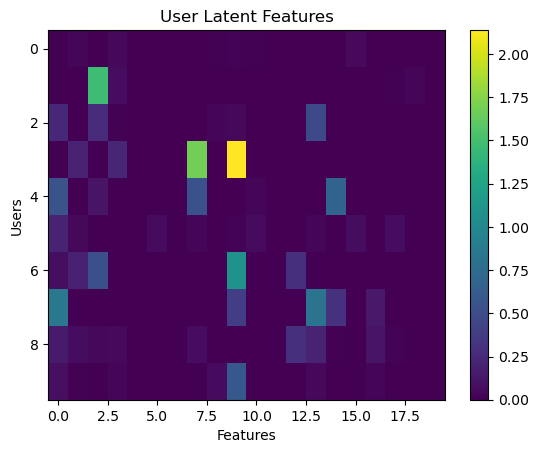

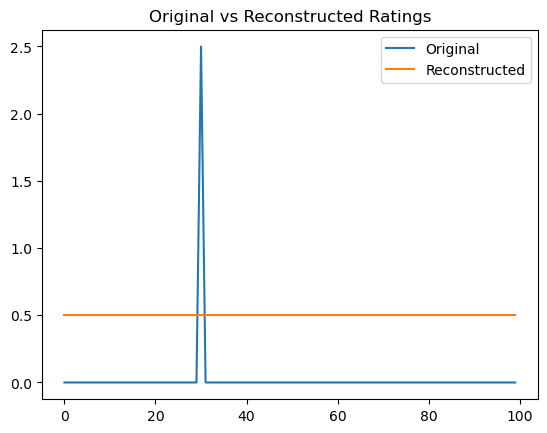

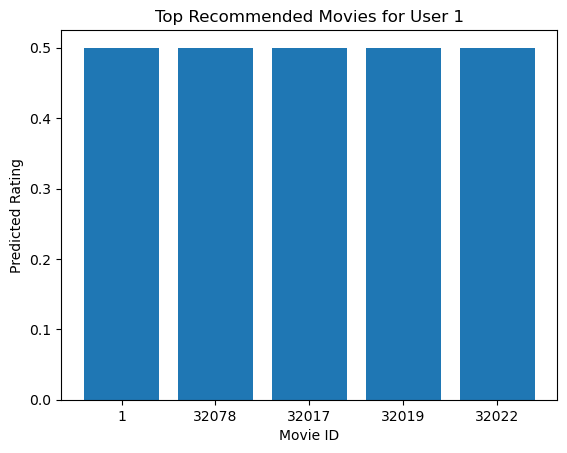

In [2]:
print("\nK.Nivedha(24BAD082)")
print("\nEXPERIMENT 10")
print("\nSCENARIO 2: MATRIX FACTORIZATION USING NMF\n")

#Import Libraries
import numpy as np
import pandas as pd
from sklearn.decomposition import NMF
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt

#Load Dataset
df = pd.read_csv(r"C:\Users\nived\Downloads\ratings_small.csv")
df = df[['userId', 'movieId', 'rating']]

#Create User-Item Matrix
user_item_matrix = df.pivot(index='userId', columns='movieId', values='rating')

#Handle Missing Values
user_item_matrix_filled = user_item_matrix.fillna(0)
R = user_item_matrix_filled.values

#Apply NMF Model
k = 20
model = NMF(n_components=k, init='nndsvd', random_state=42, max_iter=500)

#Factorization
W = model.fit_transform(R)   # User-feature matrix
H = model.components_        # Item-feature matrix

print("User-feature matrix shape:", W.shape)
print("Item-feature matrix shape:", H.shape)

#Reconstruct Matrix
R_pred = np.dot(W, H)
R_pred = np.clip(R_pred, 0.5, 5)

pred_df = pd.DataFrame(R_pred, columns=user_item_matrix.columns, index=user_item_matrix.index)

#Generate Top-N Recommendations
def recommend_movies(user_id, n=5):
    user_row = pred_df.loc[user_id]
    original = user_item_matrix.loc[user_id]

    recommendations = user_row[original.isna()].sort_values(ascending=False)
    return recommendations.head(n)

print("\nTop Recommendations for User 1:")
print(recommend_movies(1, 5))

#Evaluation Metrics

#RMSE
actual = user_item_matrix_filled.values.flatten()
predicted = R_pred.flatten()
mask = actual != 0

rmse = np.sqrt(mean_squared_error(actual[mask], predicted[mask]))
print("\nRMSE:", rmse)

#Precision@K and Recall@K
def precision_recall_at_k(user_id, k=5, threshold=3.5):
    actual_ratings = user_item_matrix.loc[user_id]
    predicted_ratings = pred_df.loc[user_id]

    #Relevant items (actual rating >= threshold)
    relevant = actual_ratings[actual_ratings >= threshold].index

    #Top-K recommended items
    recommended = predicted_ratings.sort_values(ascending=False).head(k).index

    #Intersection
    relevant_and_recommended = set(relevant).intersection(set(recommended))

    precision = len(relevant_and_recommended) / k
    recall = len(relevant_and_recommended) / len(relevant) if len(relevant) > 0 else 0

    return precision, recall

p, r = precision_recall_at_k(1, 5)
print("\nPrecision@5:", p)
print("Recall@5:", r)

#Visualization

#Latent Feature Visualization
plt.figure()
plt.imshow(W[:10], aspect='auto')
plt.title("User Latent Features")
plt.xlabel("Features")
plt.ylabel("Users")
plt.colorbar()
plt.show()

#Reconstruction Comparison
plt.figure()
plt.plot(R.flatten()[:100], label='Original')
plt.plot(R_pred.flatten()[:100], label='Reconstructed')
plt.legend()
plt.title("Original vs Reconstructed Ratings")
plt.show()

#Recommendation Ranking Chart
rec = recommend_movies(1, 5)

plt.figure()
plt.bar(range(len(rec)), rec.values)
plt.xticks(range(len(rec)), rec.index)
plt.title("Top Recommended Movies for User 1")
plt.xlabel("Movie ID")
plt.ylabel("Predicted Rating")
plt.show()

In [ ]:
1.Imported required Python libraries.
2.Loaded the MovieLens dataset.
3.Created a User-Item Matrix using pivot table.
4.Handled missing values by filling with 0.
5.Applied NMF model for matrix factorization.
6.Factorized into user-feature and item-feature matrices.
7.Reconstructed the rating matrix.
8.Predicted missing values.
9.Generated Top-N movie recommendations.
10.Evaluated model using:
    RMSE
    Precision@K
    Recall@K 
11.Visualized:
    Latent feature visualization
    Reconstruction comparison
    Recommendation ranking chart


In [ ]:
Output:

-System successfully generated recommendations using NMF
-Latent features were easily interpretable due to non-negative values
-RMSE indicated prediction performance
-Precision@K and Recall@K showed recommendation relevance
-Visualizations helped understand feature contributions and ranking